# **German Credit Risk**

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [2]:
default_of_credit_card_clients.variables.description.to_list()

[nan,
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [3]:
columns_names = [ 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',]

In [4]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23'],
      dtype='str')

In [5]:
X.columns = columns_names

## *Feature Engineer**

In [6]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


array([[<Axes: title={'center': 'Y'}>]], dtype=object)

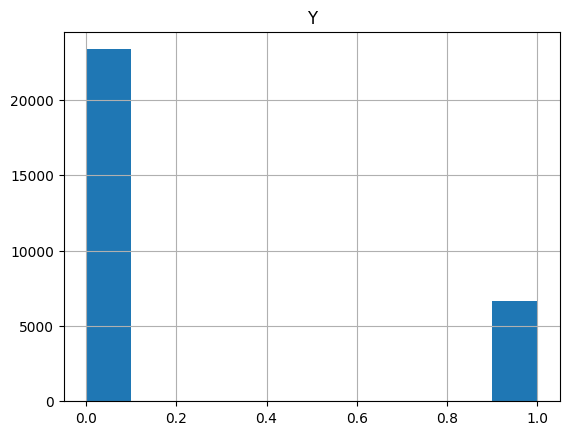

In [7]:
y.hist()

In [8]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


## **EDA** 

Analisis de todas las variables, encontrar relaciones importantes, y crear variables

In [9]:
X.LIMIT_BAL.describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

<Axes: >

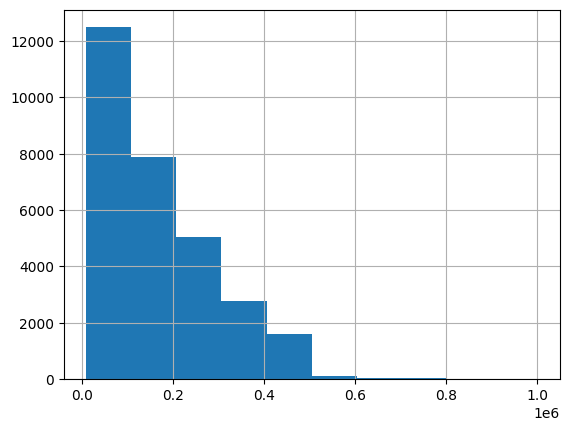

In [10]:
X.LIMIT_BAL.hist()

In [11]:
X["target"] = y

<Axes: >

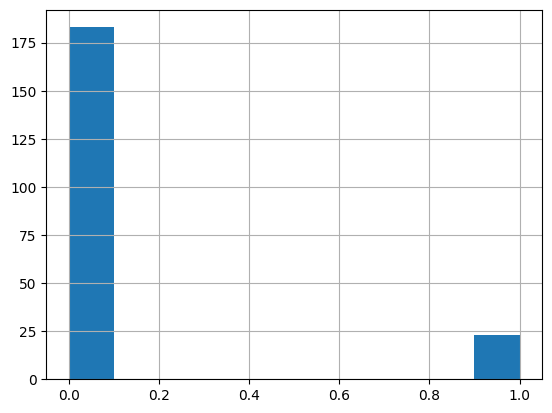

In [12]:
X[X["LIMIT_BAL"]>500000].target.hist()

### *Crear variables**

In [13]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target'],
      dtype='str')

In [14]:
import numpy as np

cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

X["flag"] = np.where(X[cols].ne(-1, 0).any(axis=1), 1, 0)

In [15]:
cols_bills = ['BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

X["AVG_BILL"] = X[cols_bills].sum(axis=1)/6

In [16]:
X["RATIO_PAY_1"] = X["PAY_AMT1"]/X["BILL_AMT1"]
X["RATIO_PAY_2"] = X["PAY_AMT2"]/X["BILL_AMT2"]
X["RATIO_PAY_3"] = X["PAY_AMT3"]/X["BILL_AMT3"]

In [17]:
X.replace([np.inf, -np.inf], 0, inplace=True)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,1,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,1,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,1,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,1,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,1,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,5003,3047,5000,1000,0,1,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8998,129,0,0,0,1,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,22000,4200,2000,3100,1,1,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1178,1926,52964,1804,1,1,44435.166667,-52.218845,0.043494,0.015438


In [18]:
X["BILL_AMT1"]

0          3913
1          2682
2         29239
3         46990
4          8617
          ...  
29995    188948
29996      1683
29997      3565
29998     -1645
29999     47929
Name: BILL_AMT1, Length: 30000, dtype: int64

## **Feature Engineer**

In [19]:
len(X)

30000

In [20]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LIMIT_BAL    30000 non-null  int64  
 1   SEX          30000 non-null  int64  
 2   EDUCATION    30000 non-null  int64  
 3   MARRIAGE     30000 non-null  int64  
 4   AGE          30000 non-null  int64  
 5   PAY_0        30000 non-null  int64  
 6   PAY_2        30000 non-null  int64  
 7   PAY_3        30000 non-null  int64  
 8   PAY_4        30000 non-null  int64  
 9   PAY_5        30000 non-null  int64  
 10  PAY_6        30000 non-null  int64  
 11  BILL_AMT1    30000 non-null  int64  
 12  BILL_AMT2    30000 non-null  int64  
 13  BILL_AMT3    30000 non-null  int64  
 14  BILL_AMT4    30000 non-null  int64  
 15  BILL_AMT5    30000 non-null  int64  
 16  BILL_AMT6    30000 non-null  int64  
 17  PAY_AMT1     30000 non-null  int64  
 18  PAY_AMT2     30000 non-null  int64  
 19  PAY_AMT3     30

In [21]:
X.isna().sum()

LIMIT_BAL         0
SEX               0
EDUCATION         0
MARRIAGE          0
AGE               0
PAY_0             0
PAY_2             0
PAY_3             0
PAY_4             0
PAY_5             0
PAY_6             0
BILL_AMT1         0
BILL_AMT2         0
BILL_AMT3         0
BILL_AMT4         0
BILL_AMT5         0
BILL_AMT6         0
PAY_AMT1          0
PAY_AMT2          0
PAY_AMT3          0
PAY_AMT4          0
PAY_AMT5          0
PAY_AMT6          0
target            0
flag              0
AVG_BILL          0
RATIO_PAY_1    1468
RATIO_PAY_2    1867
RATIO_PAY_3    2246
dtype: int64

## 1. Missing data fill

In [22]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator

In [23]:
imputer_0 = SimpleImputer(strategy='constant', fill_value=0)

In [24]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,1,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,1,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,1,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,1,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,1,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,5003,3047,5000,1000,0,1,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8998,129,0,0,0,1,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,22000,4200,2000,3100,1,1,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1178,1926,52964,1804,1,1,44435.166667,-52.218845,0.043494,0.015438


In [25]:
X_imputed = imputer_0.fit_transform(X)


## One-hot or codification strings

In [26]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
import pandas as pd

nominal_cols = ["EDUCATION"]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop = "first")
X_sex = X[nominal_cols]
sex_encoded = ohe.fit_transform(X_sex)

In [27]:
sex_encoded

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.]], shape=(30000, 6))

In [28]:
ohe.get_feature_names_out(nominal_cols)

array(['EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4',
       'EDUCATION_5', 'EDUCATION_6'], dtype=object)

In [29]:
sex_df = pd.DataFrame(sex_encoded, columns=ohe.get_feature_names_out(nominal_cols))
sex_df

,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
29995,0.0,0.0,1.0,0.0,0.0,0.0
29996,0.0,0.0,1.0,0.0,0.0,0.0
29997,0.0,1.0,0.0,0.0,0.0,0.0
29998,0.0,0.0,1.0,0.0,0.0,0.0


In [30]:
sex_df = pd.DataFrame(sex_encoded, columns=ohe.get_feature_names_out(nominal_cols))
pd.concat([X, sex_df], axis=1)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,1284.000000,0.000000,0.222115,0.000000,0.0,1.0,0.0,0.0,0.0,0.0
1,120000,2,2,2,26,-1,2,0,0,0,...,2846.166667,0.000000,0.579710,0.372856,0.0,1.0,0.0,0.0,0.0,0.0
2,90000,2,2,2,34,0,0,0,0,0,...,16942.166667,0.051917,0.106937,0.073752,0.0,1.0,0.0,0.0,0.0,0.0
3,50000,2,2,1,37,0,0,0,0,0,...,38555.666667,0.042562,0.041859,0.024345,0.0,1.0,0.0,0.0,0.0,0.0
4,50000,1,2,1,57,-1,0,-1,0,0,...,18223.166667,0.232099,6.469312,0.279057,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,120891.500000,0.044986,0.103726,0.024011,0.0,0.0,1.0,0.0,0.0,0.0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3530.333333,1.091503,1.928884,2.569389,0.0,0.0,1.0,0.0,0.0,0.0
29997,30000,1,2,2,37,4,3,2,-1,0,...,11749.333333,0.000000,0.000000,7.976795,0.0,1.0,0.0,0.0,0.0,0.0
29998,80000,1,3,1,41,1,-1,0,0,0,...,44435.166667,-52.218845,0.043494,0.015438,0.0,0.0,1.0,0.0,0.0,0.0


In [31]:
## Lo de arriba es explicativo, si tengo todo numerico no deberia hacer one-hot
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,1,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,1,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,1,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,1,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,1,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,5003,3047,5000,1000,0,1,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8998,129,0,0,0,1,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,22000,4200,2000,3100,1,1,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1178,1926,52964,1804,1,1,44435.166667,-52.218845,0.043494,0.015438


## Escalamiento

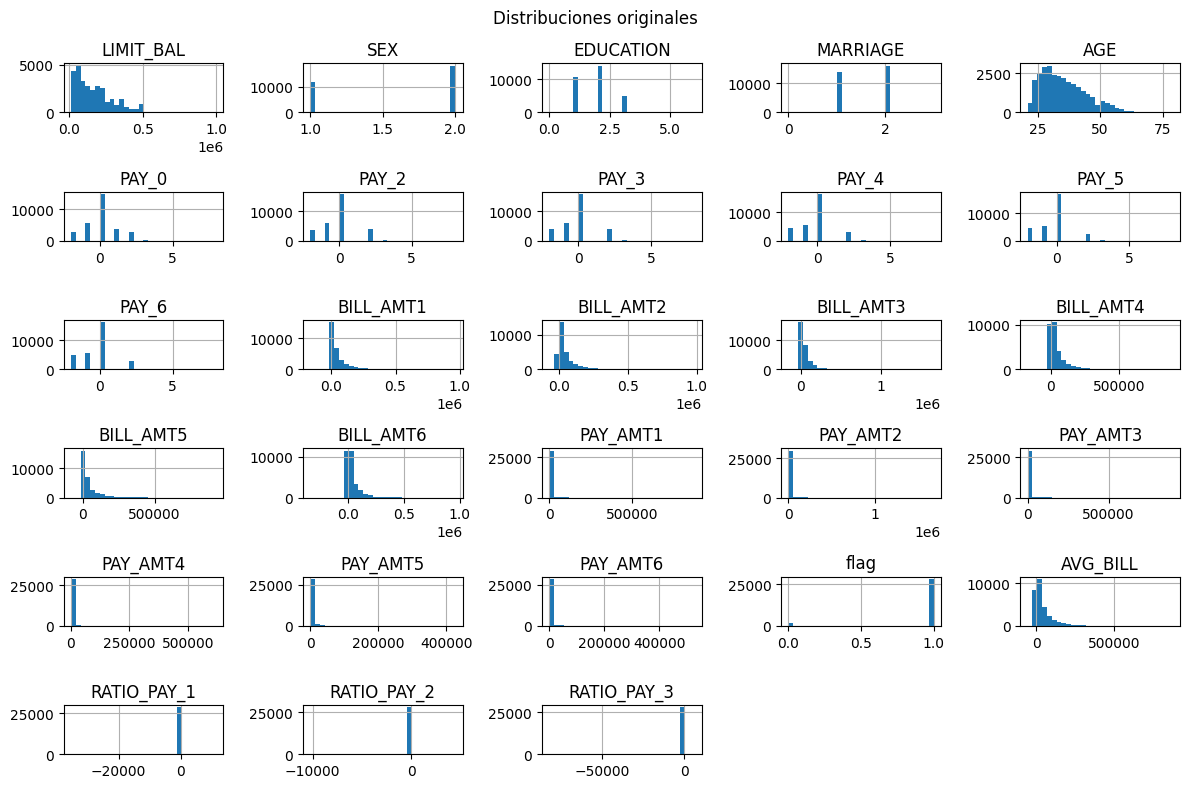

In [32]:
import matplotlib.pyplot as plt

X.drop(columns='target').hist(figsize=(12, 8), bins=30)
plt.suptitle('Distribuciones originales')
plt.tight_layout()
plt.show()

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit_transform(X)

array([[-1.13672015,  0.81016074,  0.18582826, ...,  0.00988139,
         0.01883207,  0.01071792],
       [-0.3659805 ,  0.81016074,  0.18582826, ...,  0.00988139,
         0.02214697,  0.01131364],
       [-0.59720239,  0.81016074,  0.18582826, ...,  0.01010046,
         0.01776437,  0.01083576],
       ...,
       [-1.05964618, -1.23432296,  0.18582826, ...,  0.00988139,
         0.01677307,  0.02346247],
       [-0.67427636, -1.23432296,  1.45111372, ..., -0.21046544,
         0.01717625,  0.01074259],
       [-0.90549825, -1.23432296,  0.18582826, ...,  0.01006433,
         0.01711426,  0.01076383]], shape=(30000, 29))

In [36]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,1,1,1284.000000,0.000000,0.222115,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,0,2000,1,1,2846.166667,0.000000,0.579710,0.372856
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,1000,5000,0,1,16942.166667,0.051917,0.106937,0.073752
3,50000,2,2,1,37,0,0,0,0,0,...,1200,1100,1069,1000,0,1,38555.666667,0.042562,0.041859,0.024345
4,50000,1,2,1,57,-1,0,-1,0,0,...,10000,9000,689,679,0,1,18223.166667,0.232099,6.469312,0.279057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,5003,3047,5000,1000,0,1,120891.500000,0.044986,0.103726,0.024011
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8998,129,0,0,0,1,3530.333333,1.091503,1.928884,2.569389
29997,30000,1,2,2,37,4,3,2,-1,0,...,22000,4200,2000,3100,1,1,11749.333333,0.000000,0.000000,7.976795
29998,80000,1,3,1,41,1,-1,0,0,0,...,1178,1926,52964,1804,1,1,44435.166667,-52.218845,0.043494,0.015438


## Implementacion punta a punta

In [39]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

numeric_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),#, fill_value = 0)),
    ('scaler', StandardScaler())
])

categorical_simple = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])


In [40]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target',
       'flag', 'AVG_BILL', 'RATIO_PAY_1', 'RATIO_PAY_2', 'RATIO_PAY_3'],
      dtype='str')

In [41]:
num_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'flag', 'AVG_BILL', 'RATIO_PAY_1', 'RATIO_PAY_2', 'RATIO_PAY_3']
cat_cols = ["EDUCATION"]

In [42]:

preprocess_simple = ColumnTransformer(transformers=[
    ('num', numeric_simple, num_cols),
    ('cat', categorical_simple, cat_cols)
])

In [43]:
model_simple = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', LogisticRegression(max_iter=2000))
])

In [44]:
X_dropped = X.drop(columns='target')
y = X['target']
X_train, X_test, y_train, y_test = train_test_split(X_dropped, y, test_size=0.25, stratify=y, random_state=12345)

In [45]:
X_train

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
26159,370000,2,3,2,31,-1,-1,-1,2,-1,...,42921,0,3728,2300,43183,1,14242.000000,0.597004,25.639785,0.000000
19218,220000,2,2,1,35,0,0,0,0,0,...,3000,1160,1000,0,1000,1,23913.166667,0.048474,0.080075,0.029372
7284,110000,2,2,2,24,1,2,2,0,0,...,0,10452,6475,51179,7760,1,48651.666667,0.057296,0.000000,0.153606
11304,500000,1,2,2,30,0,0,-2,-2,-2,...,3634,0,1907,0,210000,1,123957.833333,0.023729,0.009617,-0.000000
11172,60000,2,3,2,26,0,0,0,0,0,...,2000,1000,959,1300,500,1,40405.000000,0.035810,0.042063,0.020622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18194,450000,1,3,2,38,0,0,0,0,0,...,11000,10013,20000,30000,30000,1,291240.500000,0.046526,0.036482,0.034513
28812,420000,2,2,2,37,0,0,0,0,0,...,1608,1700,2500,5065,1500,1,18848.833333,0.121433,0.098246,0.095996
3826,230000,1,3,1,38,-2,-2,-1,-1,0,...,188,6498,40000,12000,2500,1,19090.000000,0.000000,0.000000,34.563830
11283,30000,2,2,2,25,1,2,2,2,2,...,1200,0,2200,0,2500,1,27689.666667,0.060223,0.043706,0.000000


In [46]:
X_test

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,flag,AVG_BILL,RATIO_PAY_1,RATIO_PAY_2,RATIO_PAY_3
29158,50000,2,3,1,56,0,0,0,0,0,...,5000,1000,10160,16669,692,1,32134.500000,0.037983,0.113541,0.024681
12903,100000,1,3,2,27,0,0,0,0,0,...,2556,2802,1786,1850,2000,1,71400.000000,0.041987,0.025787,0.042360
19815,230000,2,2,1,40,0,0,0,0,0,...,2100,1500,1000,1000,1000,1,35156.666667,0.058985,0.059935,0.041013
16643,120000,1,1,2,35,-1,-1,-1,-1,-1,...,176,0,1428,0,476,1,351.000000,1.000000,0.539877,0.000000
29627,110000,1,2,2,35,0,0,0,0,0,...,3000,2000,2000,2000,2000,1,78503.000000,0.057217,0.027069,0.018192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15494,20000,1,2,2,35,0,0,0,0,0,...,1363,1249,1000,2000,1000,1,19765.333333,0.066939,0.069209,0.062622
7730,50000,2,3,1,53,-1,-1,-1,-1,-1,...,5000,5000,4200,4810,4763,0,4469.833333,0.834376,1.299376,1.067920
27307,20000,1,2,1,37,0,0,0,0,0,...,2100,1000,132,47,0,1,7488.833333,0.095403,0.228733,0.137627
22486,480000,2,3,1,41,0,0,0,0,0,...,45000,12022,14000,14000,10000,1,78955.666667,0.799128,0.606862,0.111651


In [113]:
model_simple.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string w

In [48]:
model_simple.predict(X_test)

array([0, 0, 0, ..., 0, 0, 1], shape=(7500,))

In [49]:
model_simple.predict_proba(X_test)

array([[0.76971814, 0.23028186],
       [0.81396227, 0.18603773],
       [0.78015499, 0.21984501],
       ...,
       [0.73534826, 0.26465174],
       [0.90725339, 0.09274661],
       [0.24600577, 0.75399423]], shape=(7500, 2))

In [50]:
model_simple.predict_proba(X_test)[:, 1]

array([0.23028186, 0.18603773, 0.21984501, ..., 0.26465174, 0.09274661,
       0.75399423], shape=(7500,))

In [51]:
pred_proba_simple = model_simple.predict_proba(X_test)[:, 1]
print('AUC simple imputer:', round(roc_auc_score(y_test, pred_proba_simple), 4))

AUC simple imputer: 0.7304


1. Interpretacion Metricas

In [55]:
y_pred = model_simple.predict(X_test)
y_pred_proba =  model_simple.predict_proba(X_test)[:, 1]

In [53]:
y_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(7500,))

In [56]:
y_pred_proba

array([0.23028186, 0.18603773, 0.21984501, ..., 0.26465174, 0.09274661,
       0.75399423], shape=(7500,))

In [54]:
y_test

29158    0
12903    0
19815    0
16643    0
29627    0
        ..
15494    1
7730     0
27307    0
22486    0
22724    0
Name: target, Length: 7500, dtype: int64

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

metrics_df = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'valor': [acc, prec, rec, f1, auc]
})
metrics_df

,metrica,valor
0,Accuracy,0.812267
1,Precision,0.742747
2,Recall,0.231465
3,F1,0.352941
4,AUC,0.730375


In [58]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
cm_df

,Pred 0,Pred 1
Real 0,5708,133
Real 1,1275,384


In [60]:
5708/(5708+133)

0.9772299263824687

In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      5841
           1       0.74      0.23      0.35      1659

    accuracy                           0.81      7500
   macro avg       0.78      0.60      0.62      7500
weighted avg       0.80      0.81      0.77      7500



1.1 Oversampling

In [65]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

model_oversampled = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('oversample', SMOTE(random_state=52)),
    ('clf', LogisticRegression(max_iter=2000))
])

model_oversampled.fit(X_train, y_train)

,steps,"[('prep', ...), ('oversample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The gi

In [66]:
y_pred_oversampled = model_oversampled.predict(X_test)
y_pred_proba_oversampled =  model_oversampled.predict_proba(X_test)[:, 1]

In [67]:
y_pred_oversampled

array([0, 0, 1, ..., 1, 0, 1], shape=(7500,))

In [68]:
y_pred_proba_oversampled

array([0.49451149, 0.44121298, 0.50004789, ..., 0.56811379, 0.21228059,
       0.89275493], shape=(7500,))

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred_oversampled)
prec = precision_score(y_test, y_pred_oversampled)
rec = recall_score(y_test, y_pred_oversampled)
f1 = f1_score(y_test, y_pred_oversampled)
auc = roc_auc_score(y_test, y_pred_proba_oversampled)

metrics_df_over = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'valor': [acc, prec, rec, f1, auc]
})
metrics_df_over

,metrica,valor
0,Accuracy,0.694533
1,Precision,0.386167
2,Recall,0.646172
3,F1,0.483427
4,AUC,0.734511


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

metrics_df = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'valor': [acc, prec, rec, f1, auc]
})
metrics_df

,metrica,valor
0,Accuracy,0.812267
1,Precision,0.742747
2,Recall,0.231465
3,F1,0.352941
4,AUC,0.730375


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1'])
cm_df

,Pred 0,Pred 1
Real 0,5708,133
Real 1,1275,384


In [ ]:
5708/(5708+133)

0.9772299263824687

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      5841
           1       0.74      0.23      0.35      1659

    accuracy                           0.81      7500
   macro avg       0.78      0.60      0.62      7500
weighted avg       0.80      0.81      0.77      7500



2. Implementar CV

In [84]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [71]:
model_simple = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', LogisticRegression(max_iter=2000))
])

In [98]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=52)

scores = cross_val_score(
    model_simple,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("CV scores:", scores)
print("Mean AUC:", scores.mean())

CV scores: [0.71389272 0.71529402 0.71411136 0.74657849 0.72391449]
Mean AUC: 0.7227582152183615


In [99]:
y_pred_kfold = cross_val_predict(model_simple, X_test, y_test, cv=cv)

In [100]:
y_pred_kfold

array([0, 0, 0, ..., 0, 0, 1], shape=(7500,))

In [101]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred_kfold)
prec = precision_score(y_test, y_pred_kfold)
rec = recall_score(y_test, y_pred_kfold)
f1 = f1_score(y_test, y_pred_kfold)
#auc = roc_auc_score(y_test, y_pred_proba_oversampled)

metrics_df_over = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'valor': [acc, prec, rec, f1]
})
metrics_df_over

,metrica,valor
0,Accuracy,0.811600
1,Precision,0.696486
2,Recall,0.262809
3,F1,0.381619


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

metrics_df = pd.DataFrame({
    'metrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'valor': [acc, prec, rec, f1, auc]
})
metrics_df

,metrica,valor
0,Accuracy,0.812267
1,Precision,0.742747
2,Recall,0.231465
3,F1,0.352941
4,AUC,0.730375


3. Feature Importance

In [117]:
model_simple.fit(X_train, y_train)

feature_names = model_simple.named_steps['prep'].get_feature_names_out()
coefficients = model_simple.named_steps['clf'].coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

feature_importance.head(20)

,feature,coefficient,abs_coefficient
33,cat__EDUCATION_5,-0.774473,0.774473
5,num__PAY_0,0.664821,0.664821
28,cat__EDUCATION_0,-0.578936,0.578936
34,cat__EDUCATION_6,0.496791,0.496791
32,cat__EDUCATION_4,-0.474331,0.474331
11,num__BILL_AMT1,-0.359403,0.359403
17,num__PAY_AMT1,-0.221705,0.221705
18,num__PAY_AMT2,-0.212124,0.212124
12,num__BILL_AMT2,0.189637,0.189637
31,cat__EDUCATION_3,0.139188,0.139188


3.1 Shap values

In [118]:
import shap

# Transform data using the fitted preprocessor
X_train_transformed = model_simple.named_steps['prep'].transform(X_train)
X_test_transformed = model_simple.named_steps['prep'].transform(X_test)

# Get transformed feature names
feature_names = model_simple.named_steps['prep'].get_feature_names_out()

# If transformed data is sparse, convert a sample to dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed_dense = X_train_transformed.toarray()
else:
    X_train_transformed_dense = X_train_transformed

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed_dense = X_test_transformed.toarray()
else:
    X_test_transformed_dense = X_test_transformed

# Build SHAP explainer
explainer = shap.LinearExplainer(
    model_simple.named_steps['clf'],
    X_train_transformed_dense,
    feature_names=feature_names
)

# Compute SHAP values
shap_values = explainer(X_test_transformed_dense)

/Users/macano/Desktop/code_personal/intro-ciencia-datos-udm/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Summary plot

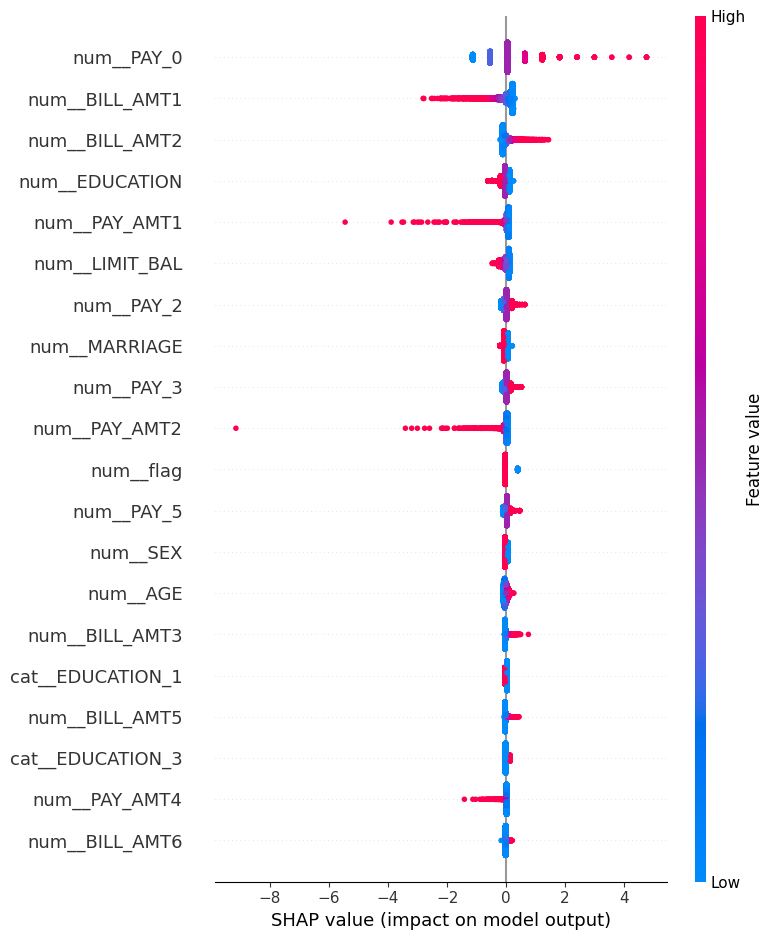

In [119]:
shap.summary_plot(shap_values.values, X_test_transformed_dense, feature_names=feature_names)

## Bar plot

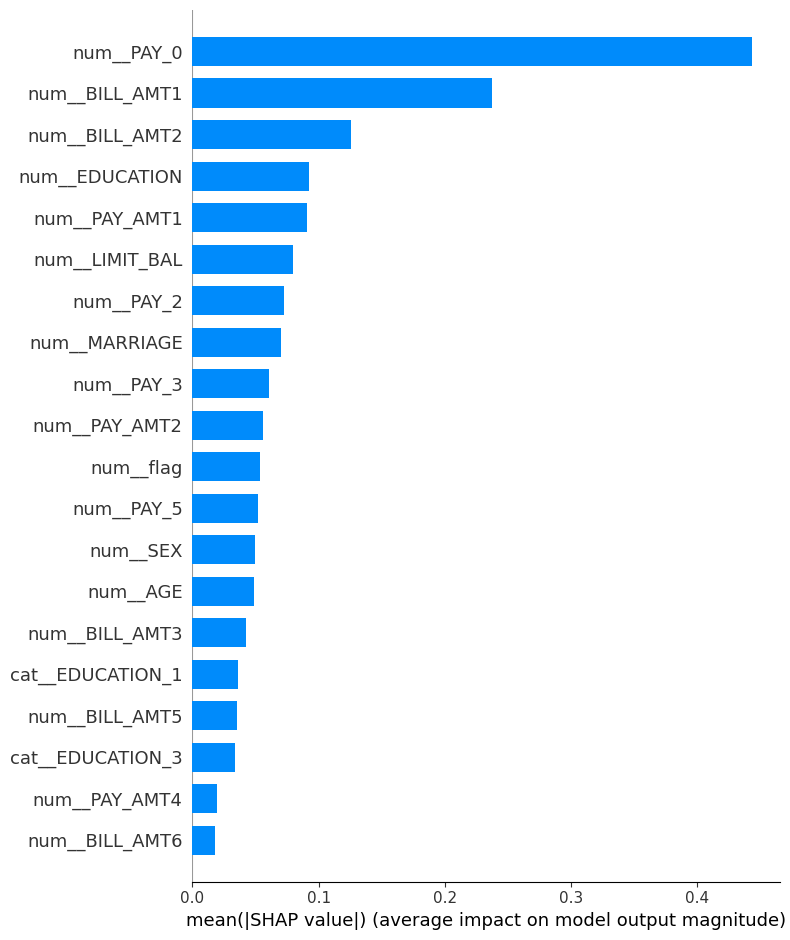

In [120]:
shap.summary_plot(shap_values.values, X_test_transformed_dense, feature_names=feature_names, plot_type="bar")

## Local explanation

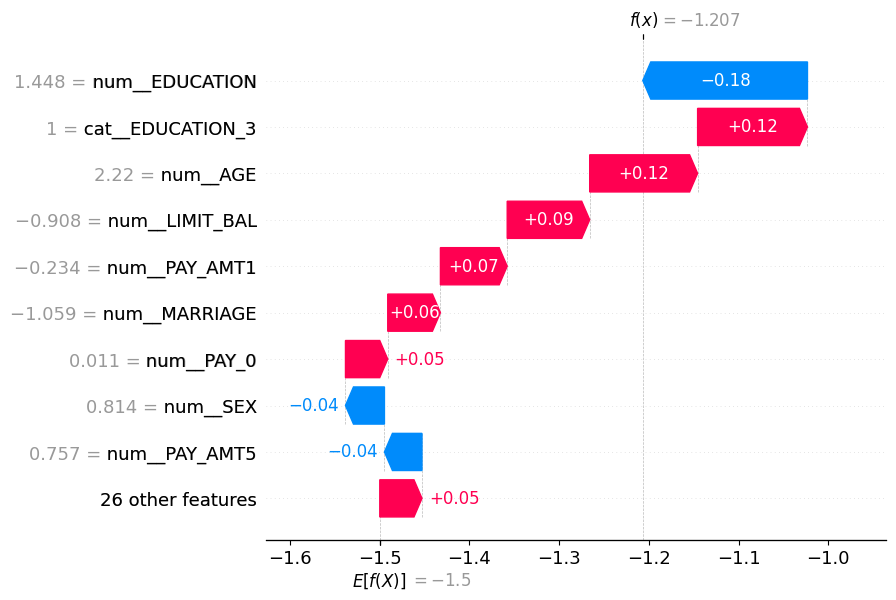

In [121]:
row_idx = 0
shap.plots.waterfall(shap_values[row_idx])

4. Jugar con otros modelos

5. Optimizar para encontrar el mejor modelo